# 1️⃣ Install Requirements

In [ ]:
pip install pandas numpy matplotlib seaborn torch scikit-learn scipy

Note: you may need to restart the kernel to use updated packages.


Dataset shape: (435742, 13)
Columns available: ['stn_code', 'sampling_date', 'state', 'location', 'agency', 'type', 'so2', 'no2', 'rspm', 'spm', 'location_monitoring_station', 'pm2_5', 'date']
Using NO2 column: no2
Valid samples: 419509
a_r = 2.0
b_r = 0.6
Epoch 0 | D: 1.3600 | G: 0.7117


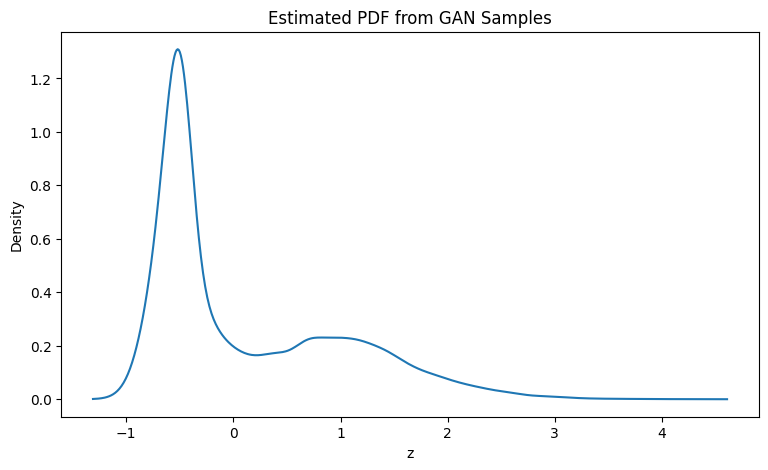

In [ ]:

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings("ignore")

# ------------------------------------------------------
# 1. LOAD DATA (JUST CHANGE PATH BELOW)
# ------------------------------------------------------

DATA_PATH = "/kaggle/input/india-air-quality-data/data.csv"  

try:
    df = pd.read_csv(DATA_PATH)
except:
    df = pd.read_csv(DATA_PATH, encoding="latin1")

print("Dataset shape:", df.shape)
print("Columns available:", list(df.columns))



no2_col = None
for col in df.columns:
    if "no2" in col.lower():
        no2_col = col
        break

if no2_col is None:
    raise Exception("NO2 column not found. Check printed columns.")

print("Using NO2 column:", no2_col)

x = pd.to_numeric(df[no2_col], errors='coerce')
x = x.replace([np.inf, -np.inf], np.nan)
x = x.dropna().values

if len(x) < 100:
    raise Exception("Too few valid NO2 samples.")

print("Valid samples:", len(x))



roll_number = 102303580

a_r = 0.5 * (roll_number % 7)
b_r = 0.3 * ((roll_number % 5) + 1)

print("a_r =", a_r)
print("b_r =", b_r)

z = x + a_r * np.sin(b_r * x)

# Normalize for GAN stability
z = (z - np.mean(z)) / np.std(z)

z_tensor = torch.tensor(z, dtype=torch.float32).view(-1,1)
loader = DataLoader(TensorDataset(z_tensor), batch_size=256, shuffle=True)



class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()
opt_G = torch.optim.Adam(G.parameters(), lr=0.0002)
opt_D = torch.optim.Adam(D.parameters(), lr=0.0002)


epochs = 1
for epoch in range(epochs):
    for real_batch, in loader:
        real_batch = real_batch.to(device)
        batch_size = real_batch.size(0)

        real_labels = torch.ones(batch_size,1).to(device)
        fake_labels = torch.zeros(batch_size,1).to(device)

        # Train Discriminator
        noise = torch.randn(batch_size,1).to(device)
        fake_samples = G(noise)

        loss_real = criterion(D(real_batch), real_labels)
        loss_fake = criterion(D(fake_samples.detach()), fake_labels)
        loss_D = loss_real + loss_fake

        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # Train Generator
        noise = torch.randn(batch_size,1).to(device)
        fake_samples = G(noise)
        loss_G = criterion(D(fake_samples), real_labels)

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

    if epoch % 200 == 0:
        print(f"Epoch {epoch} | D: {loss_D.item():.4f} | G: {loss_G.item():.4f}")

# ------------------------------------------------------
# 6. GENERATE LARGE SAMPLE & ESTIMATE PDF
# ------------------------------------------------------

with torch.no_grad():
    noise = torch.randn(60000,1).to(device)
    generated = G(noise).cpu().numpy().flatten()

kde = gaussian_kde(generated)
x_range = np.linspace(generated.min(), generated.max(), 600)
pdf = kde(x_range)

plt.figure(figsize=(9,5))
plt.plot(x_range, pdf)
plt.title("Estimated PDF from GAN Samples")
plt.xlabel("z")
plt.ylabel("Density")
plt.show()